In [27]:
from os import getenv
from typing import TypedDict
import uuid
from langchain_naver_community.tool import NaverNewsSearch
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph
from langgraph.constants import START, END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

load_dotenv()

True

In [28]:
llm = ChatOpenAI(
    model="qwen/qwen3-30b-a3b:free",
    api_key=getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [29]:
# Define the state shape
class NewsState(TypedDict):
    question: str
    date: str
    raw_news: str
    summary: str


In [30]:
# Define nodes (workflow steps)
def summarize_node(state: NewsState) -> NewsState:
    """Node that calls the LLM to answer the question."""
    messages = [
        {
            "role": "system",
            "content": (
                "You are a news analysis assistant. "
                "Given raw Naver news data, extract ONLY the articles from the given date "
                "and summarize them clearly."
            )
        },
        {
            "role": "user",
            "content": (
                f"날짜: {state['date']}\n"
                f"뉴스 데이터:\n{state['raw_news']}\n\n"
                f"위 뉴스 중 {state['date']} 날짜에 해당하는 뉴스만 골라서 요약해줘."
            )
        }
    ]
    response = llm.invoke(messages)
    return {
        **state,
        "summary": response.content
    }


def search_news_node(state: NewsState) -> NewsState:
    """Search using Naver News Search."""
    naver_search = NaverNewsSearch()

    try:
        results = naver_search.run(
            state["question"],
            target_date=state["date"],
            min_results=5,
        )
    except Exception as e:
        results = f"Search error: {str(e)}"

    return {
        **state,
        "raw_news": results
    }

In [31]:
workflow = StateGraph(NewsState)

workflow.add_node("search_news", search_news_node)
workflow.add_node("summarize", summarize_node)

workflow.add_edge(START, "search_news")
workflow.add_edge("search_news", "summarize")
workflow.add_edge("summarize", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

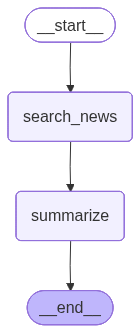

In [32]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [33]:
question = "미국 경제"
date = "2025-11-18"

initial_state = {
    "question": question,
    "date": date,
    "raw_news": "",
    "summary": ""
}

config = {"configurable": {"thread_id": str(uuid.uuid4())}}

result = graph.invoke(initial_state, config=config)

print(result["summary"])

2025-11-18 뉴스 요약:

1. **[미국 경제 지표 깜깜이 속 커지는 연준 견해차]**  
   - 트럼프 전 대통령의 경제 자문위원 출신인 마이런 연준 이사가 FOMC 회의에서 기준금리 0.50%P 인하(빅 컷)를 주창하며, 금리 인하 속도 확대를 강조.  
   - 연준 내부에서 경제 지표 부족으로 인한 정책 판단의 어려움이 두드러지고 있으며, 견해 차이가 커지고 있음.

2. **[물가 불안에 -shot다운 여파… 급격하게 떨어진 ‘금리인하 확률’]**  
   - 미국 연방정부 셧다운으로 최신 통계 활용이 어려워져 연준의 통화정책 결정에 불확실성 증가.  
   - 물가 동향과 고용 데이터의 부재로 금리인하 가능성이 감소, 경제 전망에 영향 미침.

3. **[미국 중산·저소득층 경제 악화일로…K자형 충격 더 커진다]**  
   - 모건스탠리의 리사 샬렛 CIO는 미국 경제 K자형 양극화가 심각하며, 중산층 이하 소비자들의 '진짜 균열'이 발생하고 있다고 지적.  
   - 저소득층의 재정적 압박과 고금리, 부채 부담이 경제 위험 요인으로 작용하며, 전체 경제에 타격 가능성.
